## Generative model of decision-making under risk

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def stable_prelec_function(beta, alpha, p):
    if p == 0:
        return 0
    
    try:
        log_val = -beta * (-np.log(p)) ** alpha
    except RuntimeWarning:
        log_val = float('-inf')
    
    # Clamping extremely large or small values
    if log_val > 700:  # np.log(np.finfo(np.float64).max)
        log_val = 700
    elif log_val < -700:  # np.log(np.finfo(np.float64).tiny)
        log_val = -700
    
    return np.longdouble(np.exp(log_val))

In [3]:
# Utility function of engaging in rule-breaking behavior
def utility_function(x_ij, gamma_i):
    """
    Calculate the utility of engaging in rule-breaking behavior.
    Parameters:
    x_ij (float): The amount of money.
    gamma_i (float): The utility parameter.
    Returns:
    float: The utility of engaging in rule-breaking behavior.
    """
    
    return np.sign(x_ij) * (np.abs(x_ij))**(gamma_i)


In [5]:
# Prelec's probability weighting function

def prelec(p_ij, beta_i, alpha_i):
    """
    Prelec's (1998) probability weighting function.
    
    Parameters:
    p_ij (ixj array): Probability value in the range [0, 1].
    alpha_i (float): Parameter that determines the curvature of the weighting function.
    
    Returns:
    float: Weighted probability.
    """
    if p_ij < 0 or p_ij > 1:
        raise ValueError("probability must be in the range [0, 1]")
    
    # if alpha_i <= 0:
    #     raise ValueError("alpha must be positive")
    
    return np.exp(-beta_i*(-np.log(p_ij))**alpha_i)

In [6]:
def EU_rule_break(reward_rb, cost_rb, theta, p_ij, gamma_i, beta_i, alpha_i):
    """
    Decision-making function to determine whether to engage in rule-breaking behavior.
    
    Parameters:
    reward_rb (float): Instant benefit from rule-breaking behavior.
    B (float): Instant benefit of not engaging in rule-breaking behavior.
    cost_rb (float): Cost of engaging in rule-breaking behavior.
    theta (float): Initial wealth of the individual.
    p_ij (float): Probability of being caught engaging in rule-breaking behavior.
    gamma_i (float): Risk aversion parameter.
    beta_i (float): Likelihood sensitivity parameter for Prelec's probability weighting function.
    alpha_i (float): Optimism/pessimism parameter for Prelec's probability weighting function.
    
    Returns:
    str: Decision outcome.
    """
    
    # Calculate expected utility of engaging in rule-breaking behavior
    # w(p)u(θ+A)-(1-w(p))u(θ-c)
    EU_rule_breaking = ( (prelec(p_ij, beta_i, alpha_i)) * (utility_function(reward_rb + theta, gamma_i) )  ) + np.negative(- ( (1-prelec(p_ij, beta_i, alpha_i)) * utility_function(theta - cost_rb, gamma_i) )  )

    return EU_rule_breaking


In [7]:
def EU_follow_rules(reward_rf, theta, gamma_i):
    """
    Decision-making function to determine whether to engage in rule-breaking behavior.
    
    Parameters:
    reward_rf (float): Instant benefit of  engaging in rule-FOLLOWING behavior.
    theta (float): Initial wealth of the individual.
    p_ij (float): Probability of NOT being caught engaging in rule-breaking behavior.
    gamma_i (float): Risk aversion parameter.
    
    Returns:
    float: Expected utility.
    """
    
    # Calculate expected utility of not engaging in rule-breaking behavior
    EU_no_rule_breaking = utility_function(reward_rf + theta, gamma_i)
    
    return EU_no_rule_breaking


## Varying gamma (uncertainty aversion) while holding all other variables constant

In [8]:
gammas = np.linspace(0, 5, 100)
all_EU_rb = []
all_EU_no_rb = []

for gamma in gammas:
    EU_rb = EU_rule_break(reward_rb=50, cost_rb=200, theta=100, p_ij=0.9, gamma_i=gamma, beta_i=0.12, alpha_i=0.41)
    EU_no_rb = EU_follow_rules(reward_rf=10, theta=100, gamma_i=gamma)
    all_EU_rb.append(EU_rb)
    all_EU_no_rb.append(EU_no_rb)


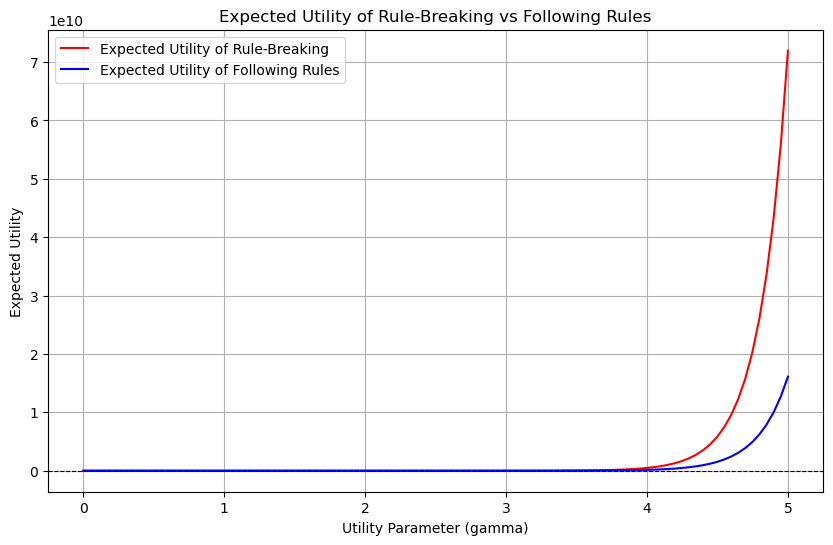

In [9]:
# plot the expected utilities
plt.figure(figsize=(10, 6))
plt.plot(gammas, all_EU_rb, label='Expected Utility of Rule-Breaking', color='red')
plt.plot(gammas, all_EU_no_rb, label='Expected Utility of Following Rules', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Expected Utility of Rule-Breaking vs Following Rules')
plt.xlabel('Utility Parameter (gamma)')
plt.ylabel('Expected Utility')
plt.legend()
plt.grid()
plt.show()

## Varying benefit of rule breaking behavior while holding all other variables constant

In [16]:
As = np.linspace(0, 300, 100)
all_EU_rbA = []
all_EU_no_rbA = []

for a in As:
    EU_rb = EU_rule_break(reward_rb=a, cost_rb=200, theta=100, p_ij=0.9, gamma_i=0.3, beta_i=0.12, alpha_i=0.41)
    EU_no_rb = EU_follow_rules(reward_rf=10, theta=100, gamma_i=0.3)
    all_EU_rbA.append(EU_rb)
    all_EU_no_rbA.append(EU_no_rb)

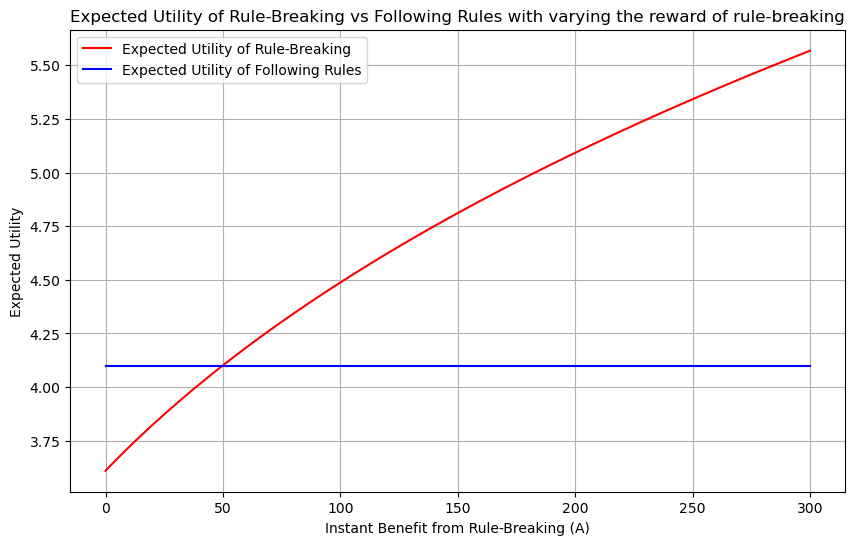

In [17]:
# plotting the results
plt.figure(figsize=(10, 6))
plt.plot(As, all_EU_rbA, label='Expected Utility of Rule-Breaking', color='red')
plt.plot(As, all_EU_no_rbA, label='Expected Utility of Following Rules', color='blue')
plt.title('Expected Utility of Rule-Breaking vs Following Rules with varying the reward of rule-breaking') 
plt.xlabel('Instant Benefit from Rule-Breaking (A)')
plt.ylabel('Expected Utility')
plt.legend()
plt.grid()
plt.show()

## Varying instant benefit of rule-following while holding all other variables constant

In [19]:
B = np.linspace(0, 200, 100)
all_EU_rbB = []
all_EU_no_rbB = []
for b in B:
    EU_rb = EU_rule_break(reward_rb=50, cost_rb=200, theta=100, p_ij=0.9, gamma_i=0.3, beta_i=0.12, alpha_i=0.41)
    EU_no_rb = EU_follow_rules(reward_rf=b, theta=100, gamma_i=0.3)
    all_EU_rbB.append(EU_rb)
    all_EU_no_rbB.append(EU_no_rb)

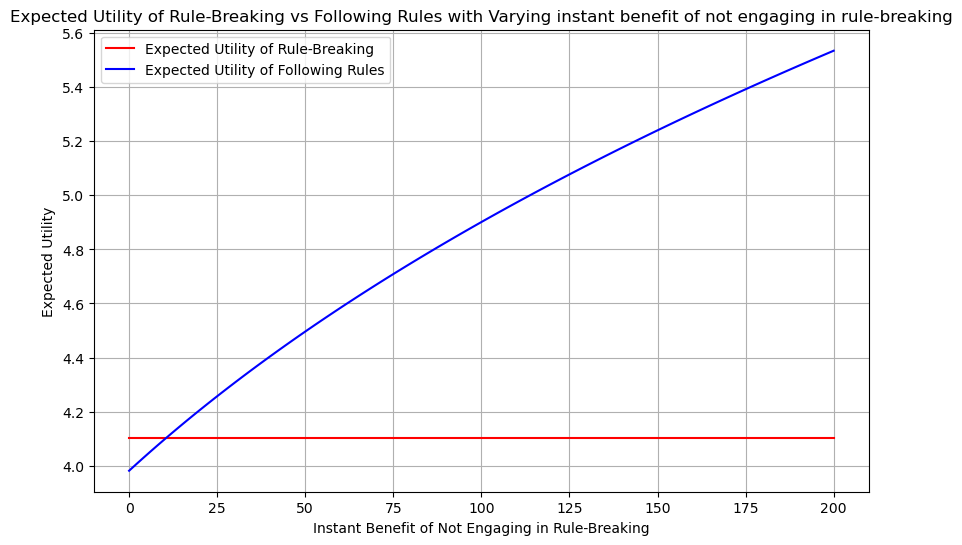

In [20]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(B, all_EU_rbB, label='Expected Utility of Rule-Breaking', color='red')
plt.plot(B, all_EU_no_rbB, label='Expected Utility of Following Rules', color='blue')
plt.title('Expected Utility of Rule-Breaking vs Following Rules with Varying instant benefit of not engaging in rule-breaking')
plt.xlabel('Instant Benefit of Not Engaging in Rule-Breaking')
plt.ylabel('Expected Utility')
plt.legend()
plt.grid()
plt.show()

## Varying cost of engaging in rule-breaking behavior while holding all other variables constant

In [31]:
C = np.linspace(10, 500, 100)
all_EU_rbC = []
all_EU_no_rbC = []
for c in C:
    EU_rb = EU_rule_break(reward_rb=50, cost_rb=c, theta=150, p_ij=0.9, gamma_i=0.3, beta_i=0.12, alpha_i=0.41)
    EU_no_rb = EU_follow_rules(reward_rf=20, theta=150, gamma_i=0.3)
    all_EU_rbC.append(EU_rb)
    all_EU_no_rbC.append(EU_no_rb)

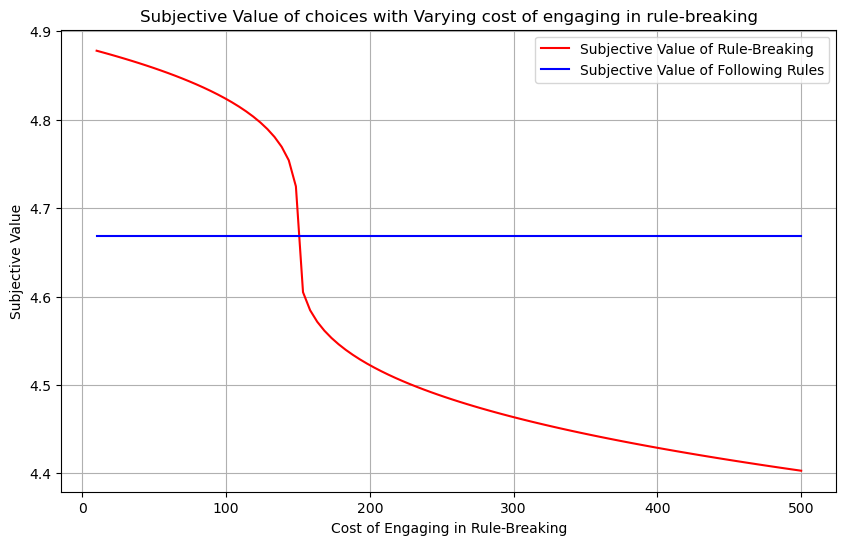

In [32]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(C, all_EU_rbC, label='Subjective Value of Rule-Breaking', color='red')
plt.plot(C, all_EU_no_rbC, label='Subjective Value of Following Rules', color='blue')
plt.title('Subjective Value of choices with Varying cost of engaging in rule-breaking')
plt.xlabel('Cost of Engaging in Rule-Breaking')
plt.ylabel('Subjective Value')
plt.legend()
plt.grid()
plt.show()


## Varying theta (initial wealth) while holding all other variables constant

In [23]:
theta = np.linspace(-100, 1000, 1000)
all_EU_rbtheta = []
all_EU_no_rbtheta = []
for t in theta:
    EU_rb = EU_rule_break(reward_rb=50, cost_rb=200, theta=t, p_ij=0.1, gamma_i=0.3, beta_i=12, alpha_i=0.41)
    EU_no_rb = EU_follow_rules(reward_rf=10, theta=t, gamma_i=0.3)
    all_EU_rbtheta.append(EU_rb)
    all_EU_no_rbtheta.append(EU_no_rb)

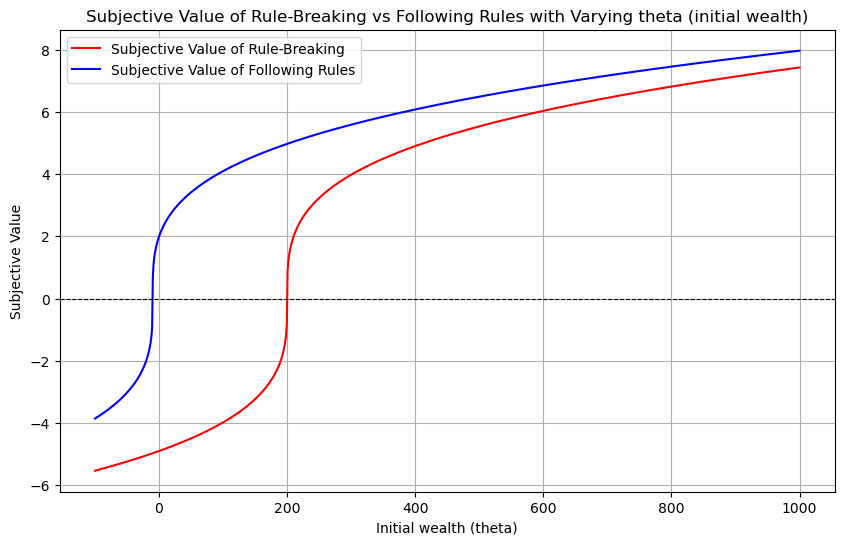

In [24]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(theta, all_EU_rbtheta, label='Subjective Value of Rule-Breaking', color='red')
plt.plot(theta, all_EU_no_rbtheta, label='Subjective Value of Following Rules', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Subjective Value of Rule-Breaking vs Following Rules with Varying theta (initial wealth)')
plt.xlabel('Initial wealth (theta)')
plt.ylabel('Subjective Value')
plt.legend()
plt.grid()
plt.show()

## Varying alpha (likelihood insensitivity) while holding all other variables constant
Values closer to 0 indicate thst the person is more insensitive and does not distinguish likelihoods well

The higher alpha is, the greater the insensitivity, meaning that at high levels of alpha, no distinction is made between likelihoods

In [29]:
alpha = np.linspace(-3, 3, 100)
all_EU_rbalpha = []
all_EU_no_rbalpha = []
for a in alpha:
    EU_rb = EU_rule_break(reward_rb=50, cost_rb=200, theta=40, p_ij=0.1, gamma_i=0.3, beta_i=0.12, alpha_i=a)
    EU_no_rb = EU_follow_rules(reward_rf=10, theta=40, gamma_i=0.3)
    all_EU_rbalpha.append(EU_rb)
    all_EU_no_rbalpha.append(EU_no_rb)

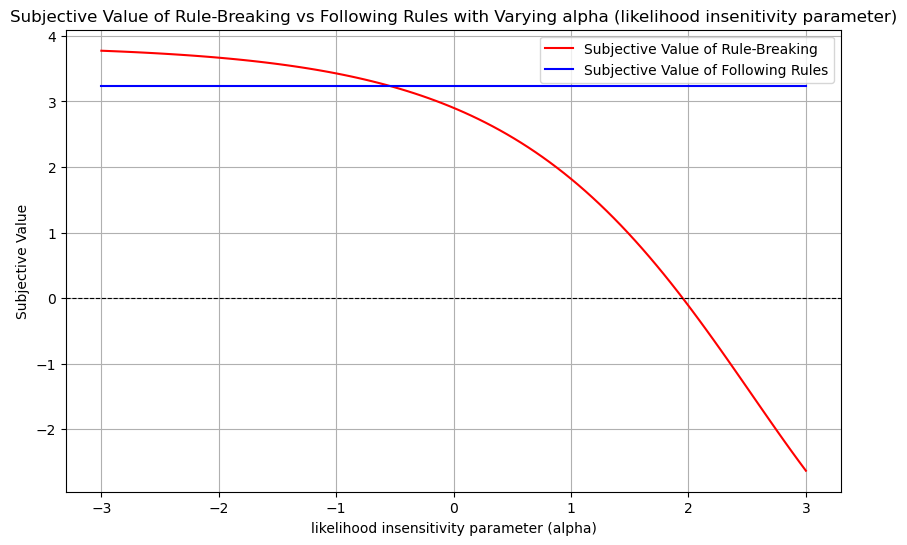

In [30]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(alpha, all_EU_rbalpha, label='Subjective Value of Rule-Breaking', color='red')
plt.plot(alpha, all_EU_no_rbalpha, label='Subjective Value of Following Rules', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Subjective Value of Rule-Breaking vs Following Rules with Varying alpha (likelihood insenitivity parameter)')
plt.xlabel('likelihood insensitivity parameter (alpha)')
plt.ylabel('Subjective Value')
plt.legend()
plt.grid()
plt.show()

## Varying beta (optimism/pessimism) while holding all other variables constant
beta < 1 indicates pessimism, while beta > 1 indicates optimism

In [36]:
beta = np.linspace(-1, 2, 100)
all_EU_rbbeta = []
all_EU_no_rbbeta = []
for b in beta:
    EU_rb = EU_rule_break(reward_rb=50, cost_rb=200, theta=40, p_ij=0.1, gamma_i=0.3, beta_i=b, alpha_i=0.41)
    EU_no_rb = EU_follow_rules(reward_rf=20, theta=40, gamma_i=0.3)
    all_EU_rbbeta.append(EU_rb)
    all_EU_no_rbbeta.append(EU_no_rb)

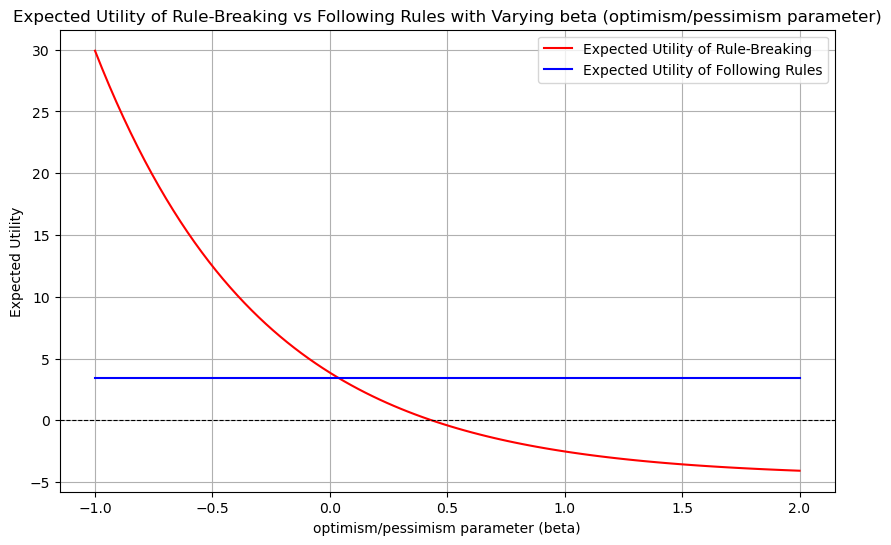

In [37]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(beta, all_EU_rbbeta, label='Expected Utility of Rule-Breaking', color='red')
plt.plot(beta, all_EU_no_rbbeta, label='Expected Utility of Following Rules', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Expected Utility of Rule-Breaking vs Following Rules with Varying beta (optimism/pessimism parameter)')
plt.xlabel('optimism/pessimism parameter (beta)')
plt.ylabel('Expected Utility')
plt.legend()
plt.grid()
plt.show()

## Varying p_ij (probability of being caught) while holding all other variables constant

In [28]:
ps = np.linspace(0.01, 1, 100)
all_EU_rbp_ij = []
all_EU_no_rbp_ij = []
for p in ps:
    EU_rb = EU_rule_break(reward_rb=50, cost_rb=200, theta=100, p_ij=p, gamma_i=0.3, beta_i=0.12, alpha_i=0.41)
    EU_no_rb = EU_follow_rules(reward_rf=20, theta=100, gamma_i=0.3)
    all_EU_rbp_ij.append(EU_rb)
    all_EU_no_rbp_ij.append(EU_no_rb)

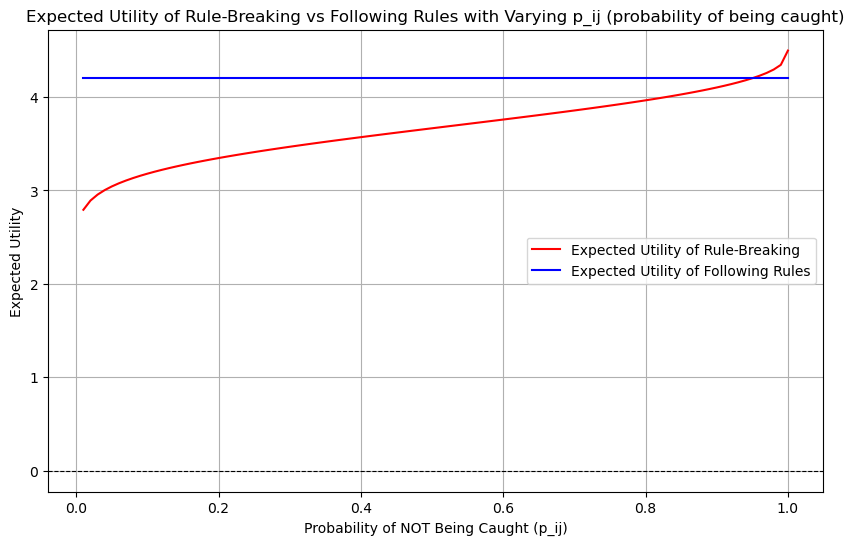

In [30]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(ps, all_EU_rbp_ij, label='Expected Utility of Rule-Breaking', color='red')
plt.plot(ps, all_EU_no_rbp_ij, label='Expected Utility of Following Rules', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Expected Utility of Rule-Breaking vs Following Rules with Varying p_ij (probability of being caught)')
plt.xlabel('Probability of NOT Being Caught (p_ij)')
plt.ylabel('Expected Utility')
plt.legend()
plt.grid()
plt.show()